In [3]:
import seaborn as sns
from pathlib import Path
import json, math, platform, warnings
warnings.filterwarnings("ignore")

import joblib
import matplotlib.pyplot as plt
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline")
import numpy as np
import pandas as pd
import scipy
import sklearn

from sklearn.base import clone
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import BaggingClassifier, ExtraTreesClassifier, RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, log_loss, matthews_corrcoef,
    precision_recall_curve, precision_score, recall_score, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay,
)
from sklearn.model_selection import (
    RandomizedSearchCV, RepeatedStratifiedKFold, StratifiedKFold,
    cross_validate, learning_curve, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree 
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [4]:
df=sns.load_dataset("iris")

print("First Five Rows")
print(df.head())

X = df.drop('species', axis=1)


y = df['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Build Logistic Regression model
model = LogisticRegression(random_state=42,max_iter=5)

# Train the model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Display Actual Species
print("\nActual Species")
print(y_test.values)

# Display Predicted Species
print("\nPredicted Species")
print(y_pred)

# Display Accuracy
print("\nAccuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")
# Display Coefficients
coefficients = model.coef_

print("\nCoefficients:")
print(coefficients)

# Display Coefficients with Feature Names
coef_df = pd.DataFrame(
    coefficients,
    columns=X.columns,
    index=model.classes_
)

print("\nCoefficient Table")
print(coef_df)

First Five Rows
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Actual Species
['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor' 'virginica' 'setosa'
 'setosa' 'setosa' 'setosa' 'versicolor' 'virginica' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'setosa' 'virginica'
 'virginica' 'virginica' 'virginica' 'virginica' 'setosa' 'setosa'
 'setosa' 'setosa' 'versicolor' 'setosa' 'setosa' 'virginica' 'versicolor'
 'setosa' 'setosa' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'setosa']

Predicted Species
['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor'

In [5]:
# Probability of each class
probabilities = model.predict_proba(X_test)

prob_df = pd.DataFrame(
    probabilities,
    columns=model.classes_
)

print("\nPrediction Probabilities")
print(prob_df)


Prediction Probabilities
      setosa  versicolor  virginica
0   0.123229    0.502511   0.374260
1   0.885067    0.096699   0.018233
2   0.011068    0.399117   0.589815
3   0.135597    0.489672   0.374731
4   0.125776    0.521736   0.352488
5   0.862301    0.113714   0.023986
6   0.279501    0.453520   0.266979
7   0.081015    0.483949   0.435036
8   0.089710    0.499989   0.410301
9   0.214512    0.484031   0.301456
10  0.087971    0.479416   0.432612
11  0.834189    0.134154   0.031657
12  0.900431    0.084561   0.015008
13  0.834214    0.134393   0.031392
14  0.889231    0.091767   0.019002
15  0.152915    0.491046   0.356039
16  0.033884    0.426710   0.539406
17  0.187984    0.488619   0.323397
18  0.126842    0.485775   0.387383
19  0.034809    0.427934   0.537258
20  0.817158    0.145311   0.037531
21  0.090019    0.474574   0.435408
22  0.836942    0.131128   0.031930
23  0.036579    0.434074   0.529347
24  0.057357    0.503780   0.438863
25  0.064176    0.467824   0.468001
26

In [6]:
# Predict Species
y_pred = model.predict(X_test)

print("Predicted Values")
print(y_pred)
# Create comparison table
results = pd.DataFrame({
    "Actual_Logistic": y_test.values,
    "Predicted_Logistic": y_pred
})

print(results)

Predicted Values
['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'versicolor' 'versicolor' 'versicolor' 'versicolor' 'setosa'
 'setosa' 'setosa' 'setosa' 'versicolor' 'virginica' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'versicolor' 'setosa' 'virginica'
 'versicolor' 'virginica' 'virginica' 'virginica' 'setosa' 'setosa'
 'setosa' 'setosa' 'versicolor' 'setosa' 'setosa' 'virginica' 'versicolor'
 'setosa' 'setosa' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'setosa']
   Actual_Logistic Predicted_Logistic
0       versicolor         versicolor
1           setosa             setosa
2        virginica          virginica
3       versicolor         versicolor
4       versicolor         versicolor
5           setosa             setosa
6       versicolor         versicolor
7        virginica         versicolor
8       versicolor         versicolor
9       versicolor         versicolor
10       virginica         versicolor
11          setosa

In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.76      1.00      0.87        13
   virginica       1.00      0.69      0.82        13

    accuracy                           0.91        45
   macro avg       0.92      0.90      0.89        45
weighted avg       0.93      0.91      0.91        45



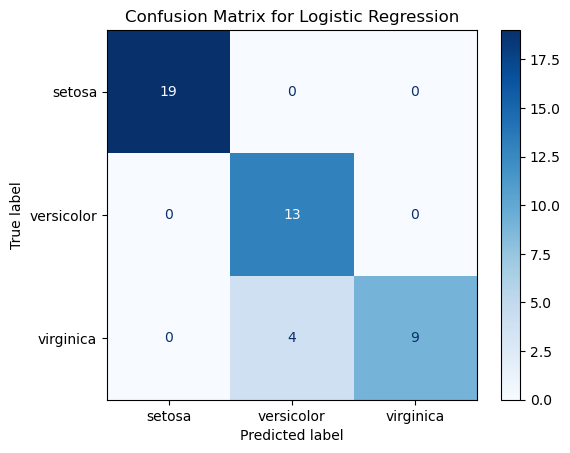